In [1]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [2]:
!pip install -q transformers scikit-learn pandas pillow matplotlib

In [3]:
import kagglehub

dataset_path = kagglehub.dataset_download(
    "sovitrath/diabetic-retinopathy-224x224-gaussian-filtered"
)

print(dataset_path)

Using Colab cache for faster access to the 'diabetic-retinopathy-224x224-gaussian-filtered' dataset.
/kaggle/input/diabetic-retinopathy-224x224-gaussian-filtered


In [4]:
from pathlib import Path

DATA_DIR = Path(
    "/kaggle/input/diabetic-retinopathy-224x224-gaussian-filtered"
)

print("Dataset exists:", DATA_DIR.exists())
print("\nContents:")

for item in DATA_DIR.iterdir():
    print(item.name)

Dataset exists: True

Contents:
gaussian_filtered_images
train.csv


In [5]:
import pandas as pd

csv_path = DATA_DIR / "train.csv"

train_metadata = pd.read_csv(csv_path)

print("Shape:", train_metadata.shape)
print("\nColumns:")
print(train_metadata.columns.tolist())

train_metadata.head()

Shape: (3662, 2)

Columns:
['id_code', 'diagnosis']


,id_code,diagnosis
0,000c1434d8d7,2
1,001639a390f0,4
2,0024cdab0c1e,1
3,002c21358ce6,0
4,005b95c28852,0


In [6]:
print(train_metadata["diagnosis"].value_counts().sort_index())

diagnosis
0    1805
1     370
2     999
3     193
4     295
Name: count, dtype: int64


In [7]:
IMAGE_DIR = DATA_DIR / "gaussian_filtered_images"

print("Number of class folders:", len(list(IMAGE_DIR.iterdir())))
print("Folders:", [x.name for x in IMAGE_DIR.iterdir()])

Number of class folders: 1
Folders: ['gaussian_filtered_images']


In [8]:
for class_dir in IMAGE_DIR.iterdir():
    if class_dir.is_dir():
        print(class_dir.name, "→", next(class_dir.iterdir()).name)

gaussian_filtered_images → Mild


In [9]:
IMAGE_DIR = DATA_DIR / "gaussian_filtered_images" / "gaussian_filtered_images"

print("Number of class folders:", len(list(IMAGE_DIR.iterdir())))
print("Folders:", [x.name for x in IMAGE_DIR.iterdir()])

Number of class folders: 6
Folders: ['Mild', 'Proliferate_DR', 'Moderate', 'export.pkl', 'No_DR', 'Severe']


In [10]:
class_dirs = [
    folder for folder in IMAGE_DIR.iterdir()
    if folder.is_dir()
]

print("Number of class folders:", len(class_dirs))
print("Classes:", [folder.name for folder in class_dirs])

Number of class folders: 5
Classes: ['Mild', 'Proliferate_DR', 'Moderate', 'No_DR', 'Severe']


In [11]:
label_names = {
    0: "No_DR",
    1: "Mild",
    2: "Moderate",
    3: "Severe",
    4: "Proliferate_DR"
}

data = []

for _, row in train_metadata.iterrows():
    image_id = row["id_code"]
    label = int(row["diagnosis"])

    # Find the image inside the corresponding class folder
    class_name = label_names[label]
    image_path = IMAGE_DIR / class_name / f"{image_id}.png"

    if image_path.exists():
        data.append({
            "image_path": str(image_path),
            "label": label,
            "class_name": class_name
        })

df = pd.DataFrame(data)

print("Total images found:", len(df))
df.head()

Total images found: 3662


,image_path,label,class_name
0,/kaggle/input/diabetic-retinopathy-224x224-gau...,2,Moderate
1,/kaggle/input/diabetic-retinopathy-224x224-gau...,4,Proliferate_DR
2,/kaggle/input/diabetic-retinopathy-224x224-gau...,1,Mild
3,/kaggle/input/diabetic-retinopathy-224x224-gau...,0,No_DR
4,/kaggle/input/diabetic-retinopathy-224x224-gau...,0,No_DR


In [12]:
print(df["label"].value_counts().sort_index())

label
0    1805
1     370
2     999
3     193
4     295
Name: count, dtype: int64


In [13]:
print("Missing images:", len(train_metadata) - len(df))

Missing images: 0


In [14]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    df,
    test_size=0.20,
    stratify=df["label"],
    random_state=42
)

print("Training samples:", len(train_df))
print("Validation samples:", len(val_df))

Training samples: 2929
Validation samples: 733


In [15]:
print("Training distribution:")
print(train_df["label"].value_counts(normalize=True).sort_index())

print("\nValidation distribution:")
print(val_df["label"].value_counts(normalize=True).sort_index())

Training distribution:
label
0    0.493001
1    0.101058
2    0.272789
3    0.052578
4    0.080574
Name: proportion, dtype: float64

Validation distribution:
label
0    0.492497
1    0.100955
2    0.272851
3    0.053206
4    0.080491
Name: proportion, dtype: float64


In [16]:
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from transformers import AutoImageProcessor

In [17]:
MODEL_NAME = "google/vit-base-patch16-224"

processor = AutoImageProcessor.from_pretrained(MODEL_NAME)

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/69.7k [00:00<?, ?B/s]

In [18]:
class DiabeticRetinopathyDataset(Dataset):

    def __init__(self, dataframe, processor):
        self.dataframe = dataframe.reset_index(drop=True)
        self.processor = processor

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        row = self.dataframe.iloc[index]

        image = Image.open(row["image_path"]).convert("RGB")

        inputs = self.processor(
            images=image,
            return_tensors="pt"
        )

        inputs = {
            key: value.squeeze(0)
            for key, value in inputs.items()
        }

        inputs["labels"] = torch.tensor(
            row["label"],
            dtype=torch.long
        )

        return inputs

In [19]:
train_dataset = DiabeticRetinopathyDataset(
    train_df,
    processor
)

val_dataset = DiabeticRetinopathyDataset(
    val_df,
    processor
)

print("Training dataset:", len(train_dataset))
print("Validation dataset:", len(val_dataset))

Training dataset: 2929
Validation dataset: 733


In [20]:
sample = train_dataset[0]

print("Keys:", sample.keys())
print("Pixel values shape:", sample["pixel_values"].shape)
print("Label:", sample["labels"])

Keys: dict_keys(['pixel_values', 'labels'])
Pixel values shape: torch.Size([3, 224, 224])
Label: tensor(0)


In [21]:
BATCH_SIZE = 16

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=True
)

In [22]:
batch = next(iter(train_loader))

print("Pixel values:", batch["pixel_values"].shape)
print("Labels:", batch["labels"].shape)
print("Device:", batch["pixel_values"].device)

Pixel values: torch.Size([16, 3, 224, 224])
Labels: torch.Size([16])
Device: cpu


In [23]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

Using device: cuda
GPU: Tesla T4


In [24]:
from transformers import ViTForImageClassification

model = ViTForImageClassification.from_pretrained(
    MODEL_NAME,
    num_labels=5,
    ignore_mismatched_sizes=True
)

model.config.id2label = {
    0: "No_DR",
    1: "Mild",
    2: "Moderate",
    3: "Severe",
    4: "Proliferate_DR"
}

model.config.label2id = {
    "No_DR": 0,
    "Mild": 1,
    "Moderate": 2,
    "Severe": 3,
    "Proliferate_DR": 4
}

model = model.to(device)

[transformers] You passed `num_labels=5` which is incompatible to the `id2label` map of length `1000`.


model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

[transformers] ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                          
------------------+----------+------------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 768]) vs model:torch.Size([5, 768])
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([5])          

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


In [25]:
print(model.classifier)
print("Device:", next(model.parameters()).device)

Linear(in_features=768, out_features=5, bias=True)
Device: cuda:0


In [26]:
batch = next(iter(train_loader))

pixel_values = batch["pixel_values"].to(device)
labels = batch["labels"].to(device)

outputs = model(
    pixel_values=pixel_values,
    labels=labels
)

print("Logits:", outputs.logits.shape)
print("Loss:", outputs.loss.item())

Logits: torch.Size([16, 5])
Loss: 1.721853256225586


In [28]:
LEARNING_RATE = 2e-5
NUM_EPOCHS = 3

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=0.01
)

print("Learning rate:", LEARNING_RATE)
print("Epochs:", NUM_EPOCHS)

Learning rate: 2e-05
Epochs: 3


In [29]:
from sklearn.metrics import accuracy_score, f1_score

In [31]:
import os

os.makedirs("outputs", exist_ok=True)

In [32]:
train_losses = []
val_losses = []
val_accuracies = []
val_f1_scores = []

best_val_f1 = 0.0

for epoch in range(NUM_EPOCHS):

    # -------------------------
    # Training
    # -------------------------
    model.train()

    total_train_loss = 0.0

    for batch in train_loader:

        pixel_values = batch["pixel_values"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()

        outputs = model(
            pixel_values=pixel_values,
            labels=labels
        )

        loss = outputs.loss

        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)

    # -------------------------
    # Validation
    # -------------------------
    model.eval()

    total_val_loss = 0.0
    all_predictions = []
    all_labels = []

    with torch.no_grad():

        for batch in val_loader:

            pixel_values = batch["pixel_values"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(
                pixel_values=pixel_values,
                labels=labels
            )

            loss = outputs.loss

            total_val_loss += loss.item()

            predictions = torch.argmax(
                outputs.logits,
                dim=1
            )

            all_predictions.extend(
                predictions.cpu().numpy()
            )

            all_labels.extend(
                labels.cpu().numpy()
            )

    avg_val_loss = total_val_loss / len(val_loader)

    val_accuracy = accuracy_score(
        all_labels,
        all_predictions
    )

    val_f1 = f1_score(
        all_labels,
        all_predictions,
        average="macro"
    )

    # Store metrics
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    val_accuracies.append(val_accuracy)
    val_f1_scores.append(val_f1)

    print(
        f"Epoch {epoch + 1}/{NUM_EPOCHS} | "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Val Loss: {avg_val_loss:.4f} | "
        f"Val Accuracy: {val_accuracy:.4f} | "
        f"Val Macro-F1: {val_f1:.4f}"
    )

    # Save best model
    if val_f1 > best_val_f1:

        best_val_f1 = val_f1

        model.save_pretrained("outputs/best_model")
        processor.save_pretrained("outputs/best_model")

        print("  ✓ Best model saved.")

Epoch 1/3 | Train Loss: 0.4932 | Val Loss: 0.5927 | Val Accuracy: 0.7763 | Val Macro-F1: 0.4877


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✓ Best model saved.
Epoch 2/3 | Train Loss: 0.3618 | Val Loss: 0.5326 | Val Accuracy: 0.7926 | Val Macro-F1: 0.6193


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✓ Best model saved.
Epoch 3/3 | Train Loss: 0.2418 | Val Loss: 0.5709 | Val Accuracy: 0.8022 | Val Macro-F1: 0.6289


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✓ Best model saved.


In [33]:
from transformers import ViTForImageClassification

best_model = ViTForImageClassification.from_pretrained(
    "outputs/best_model"
)

best_model = best_model.to(device)
best_model.eval()

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViTForImageClassification(
  (vit): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (layers): ModuleList(
      (0-11): 12 x ViTLayer(
        (attention): ViTAttention(
          (q_proj): Linear(in_features=768, out_features=768, bias=True)
          (k_proj): Linear(in_features=768, out_features=768, bias=True)
          (v_proj): Linear(in_features=768, out_features=768, bias=True)
          (o_proj): Linear(in_features=768, out_features=768, bias=True)
        )
        (layernorm_before): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (layernorm_after): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (mlp): ViTMLP(
          (activation_fn): GELUActivation()
          (fc1): Linear(in_features=768, out_features=3072, bias=True)
          (fc2): Linear(in_features=3072, out

In [34]:
from sklearn.metrics import classification_report

all_predictions = []
all_labels = []

with torch.no_grad():

    for batch in val_loader:

        pixel_values = batch["pixel_values"].to(device)
        labels = batch["labels"].to(device)

        outputs = best_model(
            pixel_values=pixel_values
        )

        predictions = torch.argmax(
            outputs.logits,
            dim=1
        )

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_labels.extend(
            labels.cpu().numpy()
        )

In [35]:
class_names = [
    "No_DR",
    "Mild",
    "Moderate",
    "Severe",
    "Proliferate_DR"
]

print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=class_names,
        digits=4
    )
)

                precision    recall  f1-score   support

         No_DR     0.9664    0.9557    0.9610       361
          Mild     0.5054    0.6351    0.5629        74
      Moderate     0.7373    0.8000    0.7674       200
        Severe     0.6111    0.2821    0.3860        39
Proliferate_DR     0.5208    0.4237    0.4673        59

      accuracy                         0.8022       733
     macro avg     0.6682    0.6193    0.6289       733
  weighted avg     0.8026    0.8022    0.7976       733



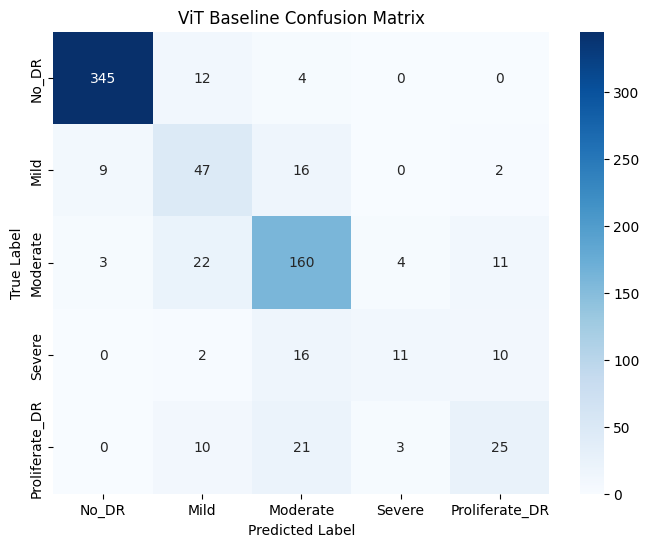

In [36]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(
    all_labels,
    all_predictions
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("ViT Baseline Confusion Matrix")

plt.show()

In [37]:
import numpy as np

class_counts = train_df["label"].value_counts().sort_index()

class_weights = len(train_df) / (
    len(class_counts) * class_counts
)

class_weights = torch.tensor(
    class_weights.values,
    dtype=torch.float32,
    device=device
)

print("Class counts:")
print(class_counts)

print("\nClass weights:")
print(class_weights)

Class counts:
label
0    1444
1     296
2     799
3     154
4     236
Name: count, dtype: int64

Class weights:
tensor([0.4057, 1.9791, 0.7332, 3.8039, 2.4822], device='cuda:0')


In [38]:
criterion = torch.nn.CrossEntropyLoss(
    weight=class_weights
)

In [39]:
class_counts = train_df["label"].value_counts().sort_index()

class_weights = len(train_df) / (
    len(class_counts) * class_counts
)

class_weights = torch.tensor(
    class_weights.values,
    dtype=torch.float32,
    device=device
)

print("Class counts:")
print(class_counts)

print("\nClass weights:")
print(class_weights)

Class counts:
label
0    1444
1     296
2     799
3     154
4     236
Name: count, dtype: int64

Class weights:
tensor([0.4057, 1.9791, 0.7332, 3.8039, 2.4822], device='cuda:0')


In [40]:
criterion = torch.nn.CrossEntropyLoss(
    weight=class_weights
)

print(criterion)

CrossEntropyLoss()
